<a href="https://colab.research.google.com/github/Mhafizhrizki/praktikum-kecerdasan-buatan/blob/main/tugas_kecerdasan_buatan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, concatenate, Embedding
from tensorflow.keras.utils import plot_model


In [ ]:
df = pd.read_csv('../content/all_agree.csv')
df.head(5)

,title,label,label_score
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...",non-clickbait,0
1,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,non-clickbait,0
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,clickbait,1
3,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",non-clickbait,0
4,MPR: Amandemen UUD 1945 Tak Akan Melebar ke Ma...,non-clickbait,0


In [ ]:
df['label_score'].value_counts()

,count
label_score,
0,5297
1,3316


In [ ]:
def find_punc(x, punc):
    count = 0
    for char in x:
        if char == punc:
            count += 1
    return count

In [ ]:
df['comau_count'] = df['title'].apply(lambda x: find_punc(x, ','))
df['left_bracket_count'] = df['title'].apply(lambda x: find_punc(x, '('))
df['exclamation_count'] = df['title'].apply(lambda x: find_punc(x, '!'))
df['question_count'] = df['title'].apply(lambda x: find_punc(x, '?'))
df['right_bracket_count'] = df['title'].apply(lambda x: find_punc(x, ')'))
df['semicolon_count'] = df['title'].apply(lambda x: find_punc(x, ';'))
df['apostrophe_count'] = df['title'].apply(lambda x: find_punc(x, '\''))

In [ ]:
df.shape

(8613, 10)

In [ ]:
def find_uppercase(x):
    count = 0
    for char in x:
        if char.isupper():
            count +=1
    return count

def find_lowercase(x):
    count = 0
    for char in x:
        if char.islower():
            count += 1
    return count

def find_number(x):
    return len(re.findall('[0-9]', x))


In [ ]:
df['uppercase_count'] = df['title'].apply(find_uppercase)
df['lowercase_count'] = df['title'].apply(find_lowercase)
df['number_count'] = df['title'].apply(find_number)


In [ ]:
def clean(text):
    # Lowering letters
    text = text.lower()

    # Removing punctuations
    text = re.sub('[.,!?;:\']', '', text)

    # Tokenization
    word_tokens = word_tokenize(text)

    # Joining words
    text = ' '.join(word_tokens)

    return text

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
df['cleaned_title'] = df['title'].apply(clean)

In [ ]:
df[['title', 'cleaned_title']]

,title,cleaned_title
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...",masuk radar pilwalkot medan menantu jokowi ber...
1,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,malaysia sudutkan ri isu kabut asap hingga inv...
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,viral driver ojol di bekasi antar pesanan maka...
3,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",kemensos salurkan rp 73 m bagi korban kerusuha...
4,MPR: Amandemen UUD 1945 Tak Akan Melebar ke Ma...,mpr amandemen uud 1945 tak akan melebar ke man...
...,...,...
8608,Twice Rilis Teaser MV 'Feel Special' Jelang Co...,twice rilis teaser mv feel special jelang come...
8609,"Asap Karhutla Riau Mulai Merambah Ke Nias, BM...",asap karhutla riau mulai merambah ke nias bmkg...
8610,"Tolak RUU Pertanahan, Ribuan Petani Siap Gelar...",tolak ruu pertanahan ribuan petani siap gelar ...
8611,Ada Niat Tambah Momongan Tanpa Ikut Program Ha...,ada niat tambah momongan tanpa ikut program ha...


In [ ]:
df.columns

Index(['title', 'label', 'label_score', 'comau_count', 'left_bracket_count',
       'exclamation_count', 'question_count', 'right_bracket_count',
       'semicolon_count', 'apostrophe_count', 'uppercase_count',
       'lowercase_count', 'number_count', 'cleaned_title'],
      dtype='object')

In [ ]:
X = df.iloc[:,3:]
y = df.iloc[:,2]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=77)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(6890, 11)
(1723, 11)


In [ ]:
X_train_title = X_train['cleaned_title']
X_test_title = X_test['cleaned_title']

X_train_punc = X_train.drop('cleaned_title', axis=1)
X_test_punc = X_test.drop('cleaned_title', axis=1)

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train_title)

X_train_title = tokenizer.texts_to_sequences(X_train_title)
X_test_title = tokenizer.texts_to_sequences(X_test_title)

In [ ]:
tokenizer.word_index

{'di': 1,
 'ini': 2,
 'dan': 3,
 'yang': 4,
 'ke': 5,
 'jadi': 6,
 'kpk': 7,
 '2019': 8,
 'indonesia': 9,
 'tak': 10,
 'untuk': 11,
 'dengan': 12,
 'habibie': 13,
 'dari': 14,
 'dpr': 15,
 'polisi': 16,
 'jokowi': 17,
 'saat': 18,
 'soal': 19,
 'akan': 20,
 'uu': 21,
 'anak': 22,
 'baru': 23,
 'minta': 24,
 'ada': 25,
 'mahasiswa': 26,
 'bisa': 27,
 'hingga': 28,
 'demo': 29,
 'bikin': 30,
 '3': 31,
 'asap': 32,
 'vs': 33,
 'kota': 34,
 'revisi': 35,
 '5': 36,
 'gara': 37,
 'hari': 38,
 'papua': 39,
 'bj': 40,
 'orang': 41,
 '4': 42,
 'tahun': 43,
 '2': 44,
 'usai': 45,
 'liga': 46,
 'sebut': 47,
 'warga': 48,
 'bakal': 49,
 'rumah': 50,
 'sinopsis': 51,
 '1': 52,
 'begini': 53,
 'dalam': 54,
 'dunia': 55,
 'gelar': 56,
 'kabut': 57,
 'ibu': 58,
 'jakarta': 59,
 'siap': 60,
 'rp': 61,
 'foto': 62,
 'karena': 63,
 'jalan': 64,
 'mobil': 65,
 'sudah': 66,
 'apa': 67,
 'lebih': 68,
 'dki': 69,
 'pemerintah': 70,
 'episode': 71,
 'korban': 72,
 '2020': 73,
 'masih': 74,
 'kasus': 75,
 'air

In [ ]:
vocab_size = len(tokenizer.word_index)
vocab_size

12342

In [ ]:
import numpy as np

lengths = []
for sentence in X_train_title:
    lengths.append(len(sentence))

print('Longest sentence\t:', max(lengths))
print('Shortest sentence\t:', min(lengths))
print('Average length\t\t:', np.mean(lengths))

Longest sentence	: 19
Shortest sentence	: 2
Average length		: 9.738606676342526


In [ ]:
X_train_title = sequence.pad_sequences(X_train_title, maxlen=19)
X_test_title = sequence.pad_sequences(X_test_title, maxlen=19)

In [ ]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train.values),
    y=y_train.values
)
class_weights

array([0.80868545, 1.30988593])

In [ ]:
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(0.8086854460093896), 1: np.float64(1.3098859315589353)}

In [ ]:
print(X_train_title.shape)
print(X_test_title.shape)


(6890, 19)
(1723, 19)


In [ ]:
tf.random.set_seed(99)

lstm_input = Input(shape=(19,))
lstm = Embedding(input_dim=vocab_size+1, output_dim=32, input_length=19)(lstm_input)
lstm = LSTM(3)(lstm)
lstm = Dropout(rate=0.5)(lstm)
lstm = Dense(3, activation='sigmoid')(lstm)

lstm_model = Model(inputs=lstm_input, outputs=lstm)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
dense_input = Input(shape=(10,))
dense = Dropout(rate=0.5)(dense_input)
dense = Dense(3, activation='sigmoid')(dense)

dense_model = Model(inputs=dense_input, outputs=dense)

In [ ]:
print(X_train_punc.shape)
print(X_test_punc.shape)

(6890, 10)
(1723, 10)


In [ ]:
concat = concatenate([lstm_model.output, dense_model.output])
concat = Dense(6, activation='sigmoid')(concat)
concat = Dense(1, activation='sigmoid')(concat)

model = Model(inputs=[lstm_model.input, dense_model.input], outputs=concat)

In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['acc'])

In [ ]:
history = model.fit([X_train_title, X_train_punc], y_train,
                    batch_size=64,
                    class_weight=class_weight_dict,
                    epochs=4,
                    validation_data=([X_test_title, X_test_punc], y_test)
)

Epoch 1/4
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - acc: 0.3817 - loss: 0.7037 - val_acc: 0.3981 - val_loss: 0.7002
Epoch 2/4
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.5264 - loss: 0.6860 - val_acc: 0.8201 - val_loss: 0.6779
Epoch 3/4
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.7583 - loss: 0.6579 - val_acc: 0.8868 - val_loss: 0.6337
Epoch 4/4
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.8642 - loss: 0.5990 - val_acc: 0.8828 - val_loss: 0.5616


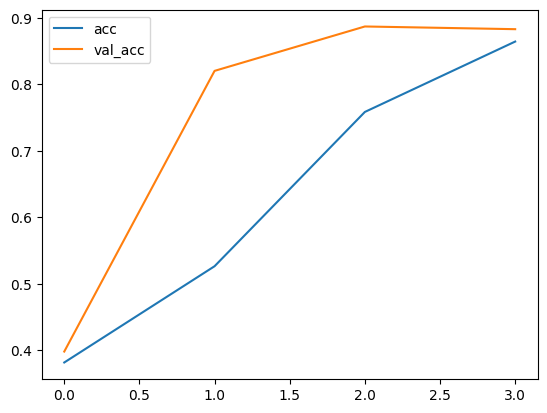

In [ ]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.legend(['acc', 'val_acc'])



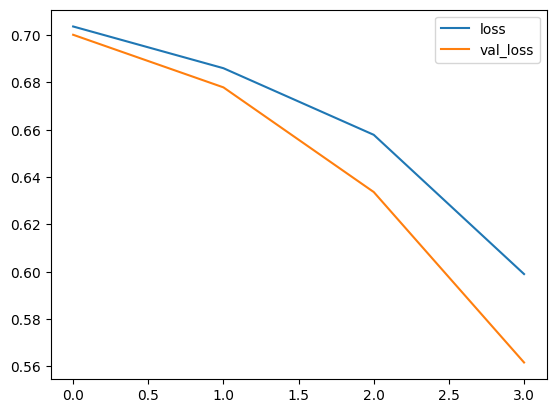

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss', 'val_loss'])